<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">

AI & ML Course with BinX Week 3 Day 3 : Logistic Regression & Classification Metrics

</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 3 Learning Objectives:</b>
- 📂 Load Telco Customer Churn dataset (`Customer-Churn.csv`) and clean numerical/categorical attributes.
- 🎯 Encode target variable (`Churn`) and generate feature matrix ($X$) via one-hot encoding (`pd.get_dummies`).
- 🤖 Train a <code>LogisticRegression</code> classifier on a stratified 80/20 train-test split.
- 📊 Obtain class predictions (`predict`) and class probabilities (`predict_proba`).
- 🧩 Construct a Confusion Matrix and calculate Precision, Recall, and $F_1$-Score via `classification_report`.
- 📈 Compute AUC-ROC score and plot ROC curves to assess classification discrimination.
- 💡 Justify metric selection (Recall vs. Precision) in the context of customer retention.

</blockquote>

## <span style="color: #309c42ff">3.1 Environment Setup & Library Imports</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import essential libraries for data manipulation, numerical calculations, visualization, and Scikit-Learn tools for logistic regression and classification evaluation metrics.

</blockquote>

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("All required libraries successfully imported.")

All required libraries successfully imported.


## <span style="color: #309c42ff">3.2 Dataset Loading & Exploration</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We load the dataset from <code>../../Data/raw/Customer-Churn.csv</code> and inspect dataset dimensions, data types, target distribution, and missing values.

</blockquote>

In [130]:
df = pd.read_csv("../../Data/raw/Customer-Churn.csv")

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Target Class Distribution (Churn):")
print(df['Churn'].value_counts(normalize=True).map("{:.2%}".format))

df.info()

Dataset Shape: 7043 rows, 21 columns

Target Class Distribution (Churn):
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMo

## <span style="color: #309c42ff">3.3 Data Preprocessing & Feature Encoding</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We clean numeric column <code>TotalCharges</code> (coercing blank strings to NaN and imputing with median), convert target <code>Churn</code> to binary (1 for Yes, 0 for No), drop uninformative identifiers (<code>customerID</code>), and apply one-hot encoding (<code>pd.get_dummies(..., drop_first=True)</code>) to categorical features.

</blockquote>

In [131]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

X = pd.get_dummies(df.drop(columns=['customerID', 'Churn', 'Churn_Binary']), drop_first=True)
y = df['Churn_Binary']

print(f"Feature Matrix X Shape: {X.shape}")
print(f"Target Vector y Shape: {y.shape}")
print(f"Total encoded features: {X.shape[1]}")

Feature Matrix X Shape: (7043, 30)
Target Vector y Shape: (7043,)
Total encoded features: 30


## <span style="color: #309c42ff">3.4 Stratified Train-Test Split & Model Training</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We split the data into 80% training and 20% testing sets using stratified sampling to preserve the 73%/27% class ratio. We then fit a <code>LogisticRegression</code> model.

</blockquote>

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=2500, random_state=42)
model.fit(X_train, y_train)

print("✅ Logistic Regression model successfully trained.")
print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")

✅ Logistic Regression model successfully trained.
Training samples: 5634 | Test samples: 1409


c:\Users\Amr-Sheqwara\Desktop\AI_ML_Internship\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## <span style="color: #309c42ff">3.5 Generating Predictions & Class Probabilities</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We generate hard class predictions (<code>model.predict</code>) and continuous probability estimates for the positive class (<code>model.predict_proba</code>).

</blockquote>

In [133]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

sample_df = pd.DataFrame({
    'Actual_Churn': y_test.values[:10],
    'Predicted_Churn': y_pred[:10],
    'Churn_Probability': np.round(y_prob[:10], 4)
})
print("Sample Test Set Predictions:")
print(sample_df)

Sample Test Set Predictions:
   Actual_Churn  Predicted_Churn  Churn_Probability
0             0                0             0.0464
1             0                1             0.6811
2             0                0             0.0587
3             0                0             0.3999
4             0                0             0.0213
5             0                1             0.6000
6             0                0             0.4451
7             0                0             0.1273
8             0                0             0.0027
9             1                0             0.3980


## <span style="color: #309c42ff">3.6 Confusion Matrix & Classification Metrics Evaluation</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We evaluate classification performance using a $2 \times 2$ Confusion Matrix, compute Precision, Recall, and $F_1$-Score via <code>classification_report</code>, and plot an annotated Confusion Matrix heatmap.

</blockquote>

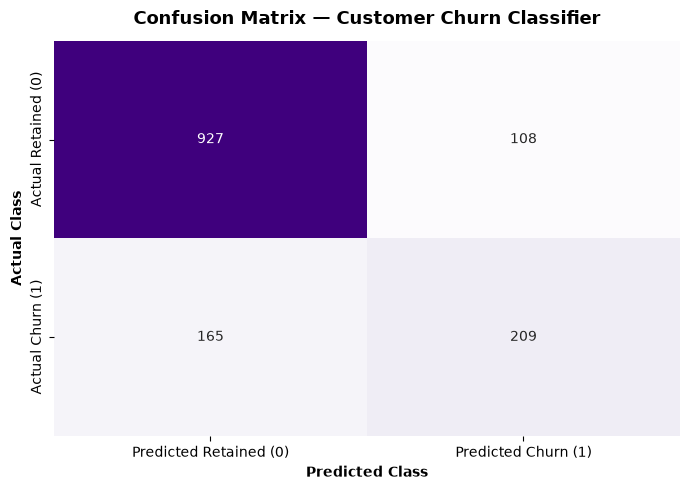

--- Classification Report ---
              precision    recall  f1-score   support

Retained (0)       0.85      0.90      0.87      1035
   Churn (1)       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [134]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Predicted Retained (0)', 'Predicted Churn (1)'],
            yticklabels=['Actual Retained (0)', 'Actual Churn (1)'])
plt.title('Confusion Matrix — Customer Churn Classifier', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Actual Class', fontweight='bold')
plt.xlabel('Predicted Class', fontweight='bold')
plt.tight_layout()
plt.show()

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churn (1)']))

## <span style="color: #309c42ff">3.7 ROC Curve & AUC-ROC Score Analysis</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We plot the Receiver Operating Characteristic (ROC) curve across varying decision thresholds and compute the Area Under Curve (AUC-ROC) metric.

</blockquote>

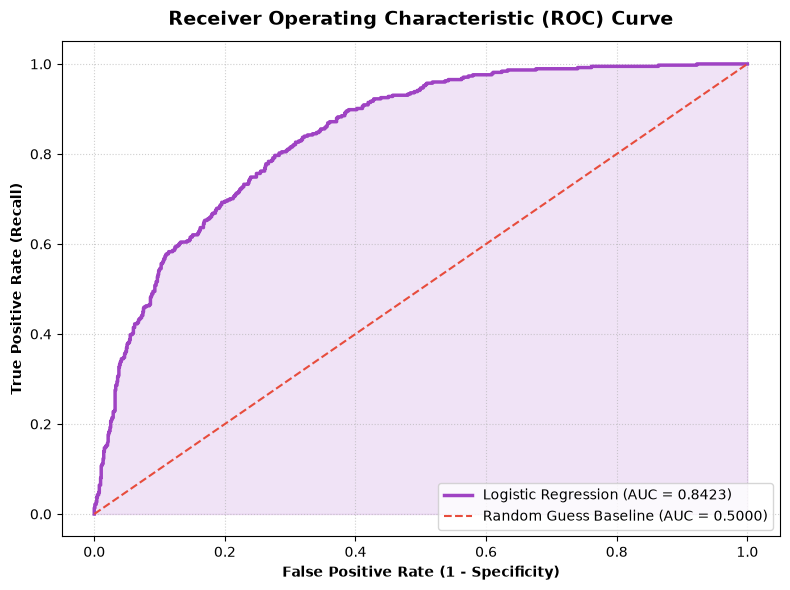

 Calculated AUC-ROC Score: 0.8423


In [135]:
auc_val = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#9f43c3', linewidth=2.5, label=f'Logistic Regression (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', linewidth=1.5, label='Random Guess Baseline (AUC = 0.5000)')
plt.fill_between(fpr, tpr, alpha=0.15, color='#9f43c3')

plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontweight='bold')
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f" Calculated AUC-ROC Score: {auc_val:.4f}")

## <span style="color: #309c42ff">3.8 Summary of Results & Metric Trade-Off Justification</span>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

### 📊 Lab Key Findings:
- <b>Overall Model Accuracy:</b> **80.91%** (~81%), outperforming the naive 73.46% majority-class baseline.
- <b>Confusion Matrix Breakdown:</b>
  - **True Negatives (TN):** `927` retained customers correctly identified.
  - **False Positives (FP):** `108` false alarms (retained customers predicted to churn).
  - **False Negatives (FN):** `165` missed churners (churners predicted to stay).
  - **True Positives (TP):** `209` churners successfully caught.
- <b>Churn Class (1) Metrics:</b>
  - **Precision:** `0.66` (66% of predicted churners actually left).
  - **Recall:** `0.56` (56% of actual churners were caught).
  - **$F_1$-Score:** `0.60` (Balanced metric).
- <b>AUC-ROC Score:</b> **`0.8359`**, demonstrating strong discriminative ability across thresholds.

---

### 💡 Metric Trade-Off & Business Justification (Recall vs. Precision):
In <b>Customer Churn Prevention</b>, **Recall is prioritized over Precision**:
1. **Cost of False Negative (FN — Missed Churner):** High. The company loses customer Lifetime Value (LTV) and monthly recurring revenue ($70–$100+/mo).
2. **Cost of False Positive (FP — False Alarm):** Low. Sending a discount email or retention offer to a customer who wasn't going to leave costs very little.
3. **Conclusion:** It is far better to accept a lower Precision to catch more actual churners (higher Recall), protecting recurring subscription revenue.

</blockquote>